In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
customer_data = pd.read_csv(r'C:\Proyectos\Credit Risk Classification\customer_data.csv')

In [48]:
customer_data.head()

,label,id,fea_1,fea_2,fea_3,fea_4,fea_5,fea_6,fea_7,fea_8,fea_9,fea_10,fea_11
0,1,54982665,5,1245.5,3,77000.0,2,15,5,109,5,151300,244.948974
1,0,59004779,4,1277.0,1,113000.0,2,8,-1,100,3,341759,207.173840
2,0,58990862,7,1298.0,1,110000.0,2,11,-1,101,5,72001,1.000000
3,1,58995168,7,1335.5,1,151000.0,2,11,5,110,3,60084,1.000000
4,0,54987320,7,NaN,2,59000.0,2,11,5,108,4,450081,197.403141


In [49]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1125 entries, 0 to 1124
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   label   1125 non-null   int64  
 1   id      1125 non-null   int64  
 2   fea_1   1125 non-null   int64  
 3   fea_2   976 non-null    float64
 4   fea_3   1125 non-null   int64  
 5   fea_4   1125 non-null   float64
 6   fea_5   1125 non-null   int64  
 7   fea_6   1125 non-null   int64  
 8   fea_7   1125 non-null   int64  
 9   fea_8   1125 non-null   int64  
 10  fea_9   1125 non-null   int64  
 11  fea_10  1125 non-null   int64  
 12  fea_11  1125 non-null   float64
dtypes: float64(3), int64(10)
memory usage: 114.4 KB


In [50]:
customer_data.describe()

,label,id,fea_1,fea_2,fea_3,fea_4,fea_5,fea_6,fea_7,fea_8,fea_9,fea_10,fea_11
count,1125.000000,1.125000e+03,1125.000000,976.000000,1125.000000,1.125000e+03,1125.000000,1125.000000,1125.000000,1125.000000,1125.000000,1125.000000,1125.000000
mean,0.200000,5.783677e+07,5.482667,1283.911373,2.333333,1.208836e+05,1.928889,10.872000,4.832889,100.802667,4.195556,164618.495111,134.999004
std,0.400178,1.817150e+06,1.383338,51.764022,0.878773,8.844523e+04,0.257125,2.676437,2.971182,11.988955,0.855679,152520.488281,112.616798
min,0.000000,5.498235e+07,1.000000,1116.500000,1.000000,1.500000e+04,1.000000,3.000000,-1.000000,64.000000,1.000000,60000.000000,1.000000
25%,0.000000,5.499050e+07,4.000000,1244.000000,1.000000,7.200000e+04,2.000000,8.000000,5.000000,90.000000,3.000000,60044.000000,1.000000
50%,0.000000,5.898975e+07,5.000000,1281.500000,3.000000,1.020000e+05,2.000000,11.000000,5.000000,105.000000,4.000000,72000.000000,173.205081
75%,0.000000,5.899799e+07,7.000000,1314.500000,3.000000,1.390000e+05,2.000000,11.000000,5.000000,111.000000,5.000000,151307.000000,202.484567
max,1.000000,5.900624e+07,7.000000,1481.000000,3.000000,1.200000e+06,2.000000,16.000000,10.000000,115.000000,5.000000,650070.000000,707.106781


In [51]:
customer_data.isnull().sum()

label       0
id          0
fea_1       0
fea_2     149
fea_3       0
fea_4       0
fea_5       0
fea_6       0
fea_7       0
fea_8       0
fea_9       0
fea_10      0
fea_11      0
dtype: int64

In [52]:
customer_data['label'].value_counts()


label
0    900
1    225
Name: count, dtype: int64

In [53]:
customer_data['label'].value_counts(normalize=True) * 100

label
0    80.0
1    20.0
Name: proportion, dtype: float64

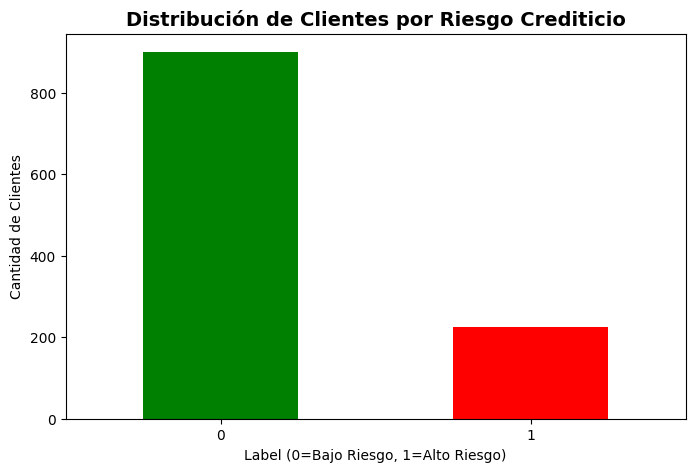

In [54]:
# Visualización
plt.figure(figsize=(8, 5))
customer_data['label'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribución de Clientes por Riesgo Crediticio', fontsize=14, fontweight='bold')
plt.xlabel('Label (0=Bajo Riesgo, 1=Alto Riesgo)')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=0)
plt.show()

In [55]:
payment_data = pd.read_csv(r'C:\Proyectos\Credit Risk Classification\payment_data.csv')

In [56]:
payment_data.head()

,id,OVD_t1,OVD_t2,OVD_t3,OVD_sum,pay_normal,prod_code,prod_limit,update_date,new_balance,highest_balance,report_date
0,58987402,0,0,0,0,1,10,16500.0,04/12/2016,0.0,NaN,NaN
1,58995151,0,0,0,0,1,5,NaN,04/12/2016,588720.0,491100.0,NaN
2,58997200,0,0,0,0,2,5,NaN,04/12/2016,840000.0,700500.0,22/04/2016
3,54988608,0,0,0,0,3,10,37400.0,03/12/2016,8425.2,7520.0,25/04/2016
4,54987763,0,0,0,0,2,10,NaN,03/12/2016,15147.6,NaN,26/04/2016


In [57]:
payment_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8250 entries, 0 to 8249
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               8250 non-null   int64  
 1   OVD_t1           8250 non-null   int64  
 2   OVD_t2           8250 non-null   int64  
 3   OVD_t3           8250 non-null   int64  
 4   OVD_sum          8250 non-null   int64  
 5   pay_normal       8250 non-null   int64  
 6   prod_code        8250 non-null   int64  
 7   prod_limit       2132 non-null   float64
 8   update_date      8224 non-null   object 
 9   new_balance      8250 non-null   float64
 10  highest_balance  7841 non-null   float64
 11  report_date      7136 non-null   object 
dtypes: float64(3), int64(7), object(2)
memory usage: 773.6+ KB


In [58]:
payment_data.isnull().sum()

id                    0
OVD_t1                0
OVD_t2                0
OVD_t3                0
OVD_sum               0
pay_normal            0
prod_code             0
prod_limit         6118
update_date          26
new_balance           0
highest_balance     409
report_date        1114
dtype: int64

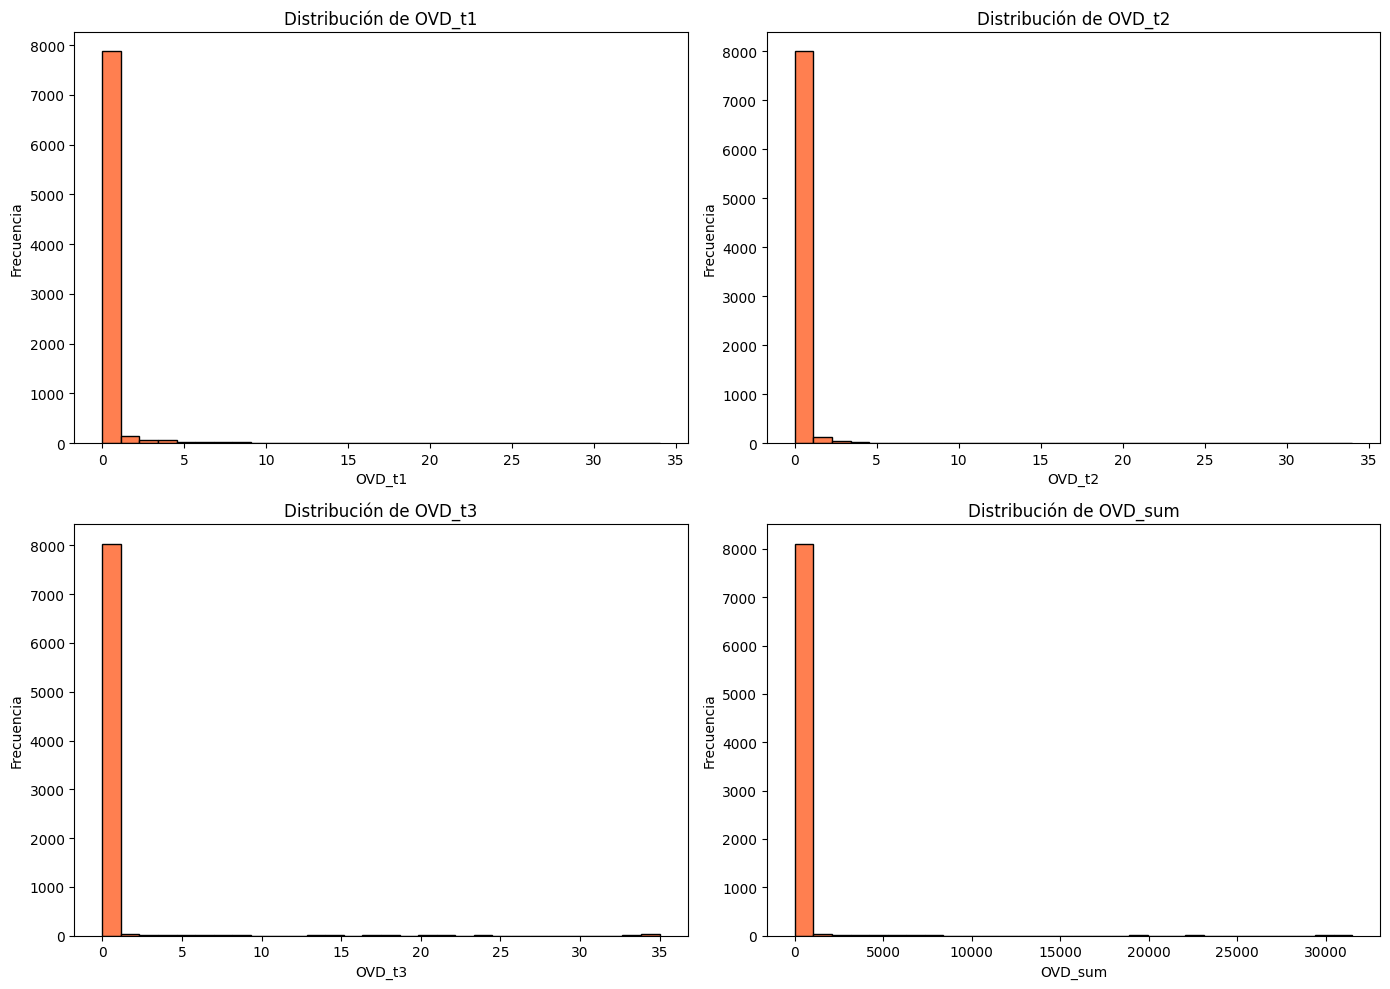

In [59]:
# 1. Distribución de las variables de atraso (OVD)
ovd_cols = ['OVD_t1', 'OVD_t2', 'OVD_t3', 'OVD_sum']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, col in enumerate(ovd_cols):
    axes[idx].hist(payment_data[col], bins=30, color='coral', edgecolor='black')
    axes[idx].set_title(f'Distribución de {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

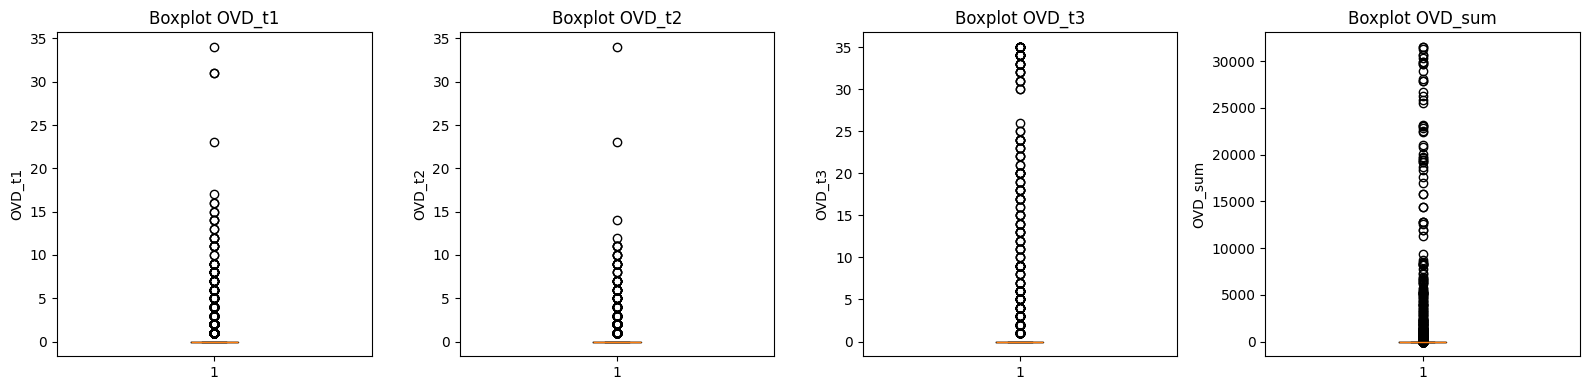

In [60]:
# 2. Boxplots de variables de atraso (detectar outliers)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for idx, col in enumerate(ovd_cols):
    axes[idx].boxplot(payment_data[col].dropna())
    axes[idx].set_title(f'Boxplot {col}')
    axes[idx].set_ylabel(col)

plt.tight_layout()
plt.show()

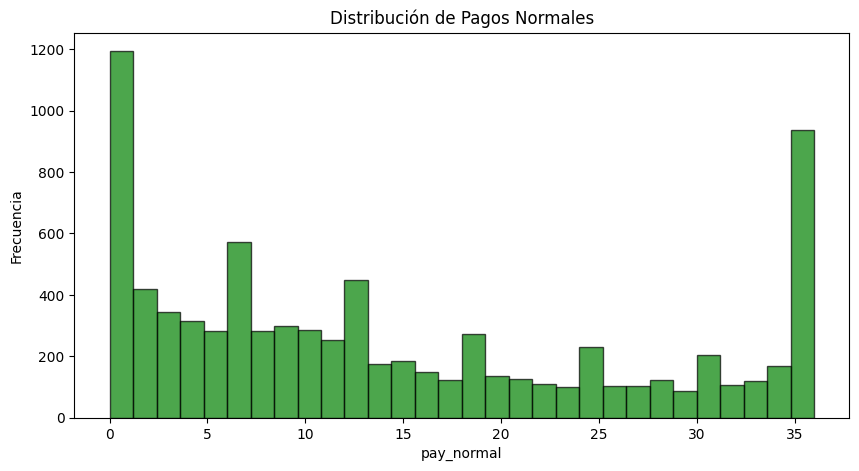

In [61]:
# 3. Distribución de pagos normales
plt.figure(figsize=(10, 5))
plt.hist(payment_data['pay_normal'], bins=30, color='green', edgecolor='black', alpha=0.7)
plt.title('Distribución de Pagos Normales')
plt.xlabel('pay_normal')
plt.ylabel('Frecuencia')
plt.show()

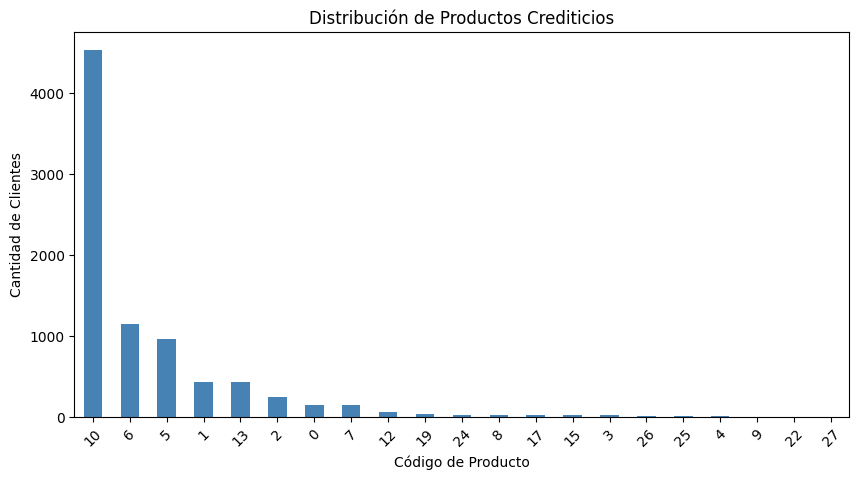

In [62]:
# 4. Distribución de productos crediticios (prod_code)
plt.figure(figsize=(10, 5))
payment_data['prod_code'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Distribución de Productos Crediticios')
plt.xlabel('Código de Producto')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=45)
plt.show()

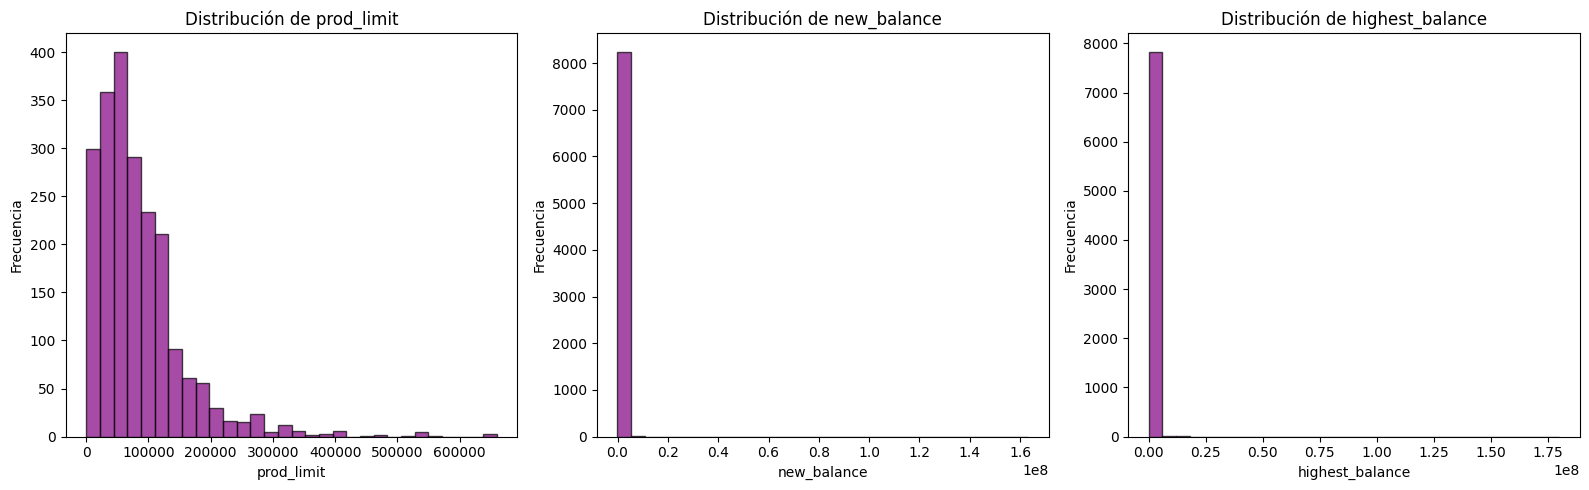

In [63]:
# 5. Distribución de límites de crédito y balances
financial_cols = ['prod_limit', 'new_balance', 'highest_balance']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, col in enumerate(financial_cols):
    axes[idx].hist(payment_data[col], bins=30, color='purple', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribución de {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

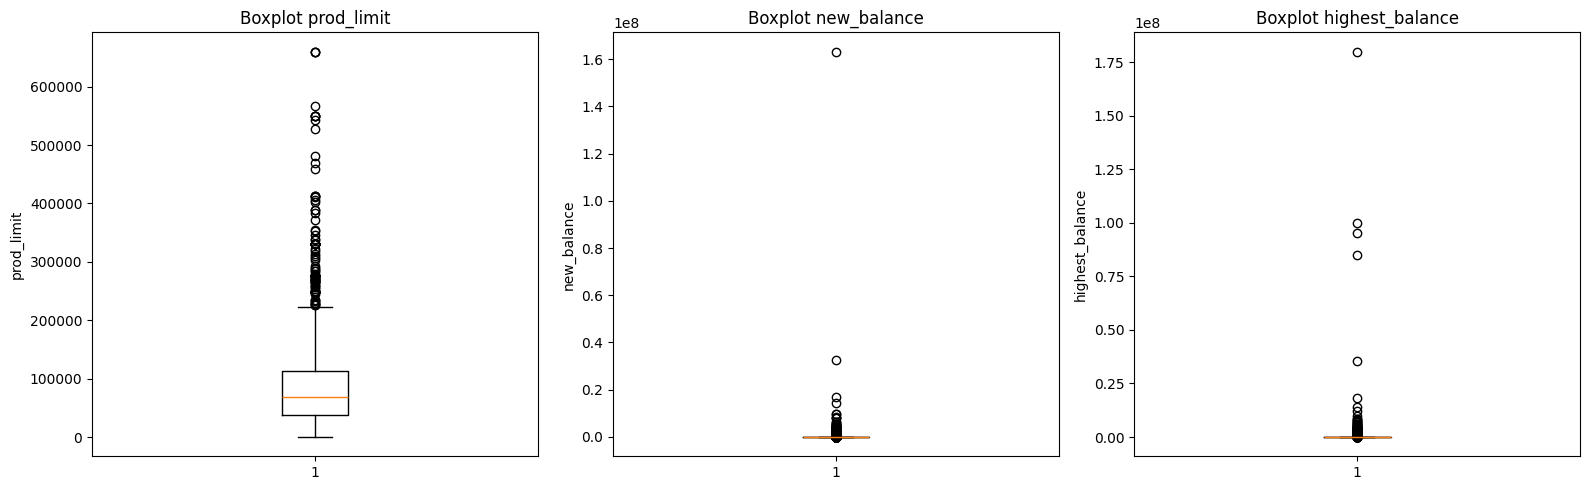

In [64]:
# 6. Boxplots de variables financieras
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, col in enumerate(financial_cols):
    axes[idx].boxplot(payment_data[col].dropna())
    axes[idx].set_title(f'Boxplot {col}')
    axes[idx].set_ylabel(col)

plt.tight_layout()
plt.show()

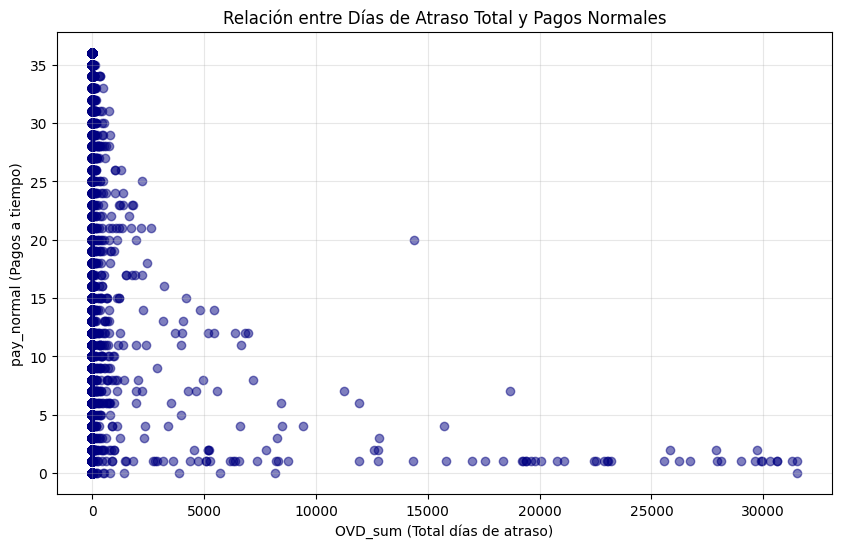

In [65]:
# 7. Relación entre OVD_sum y pay_normal
plt.figure(figsize=(10, 6))
plt.scatter(payment_data['OVD_sum'], payment_data['pay_normal'], alpha=0.5, color='navy')
plt.title('Relación entre Días de Atraso Total y Pagos Normales')
plt.xlabel('OVD_sum (Total días de atraso)')
plt.ylabel('pay_normal (Pagos a tiempo)')
plt.grid(True, alpha=0.3)
plt.show()

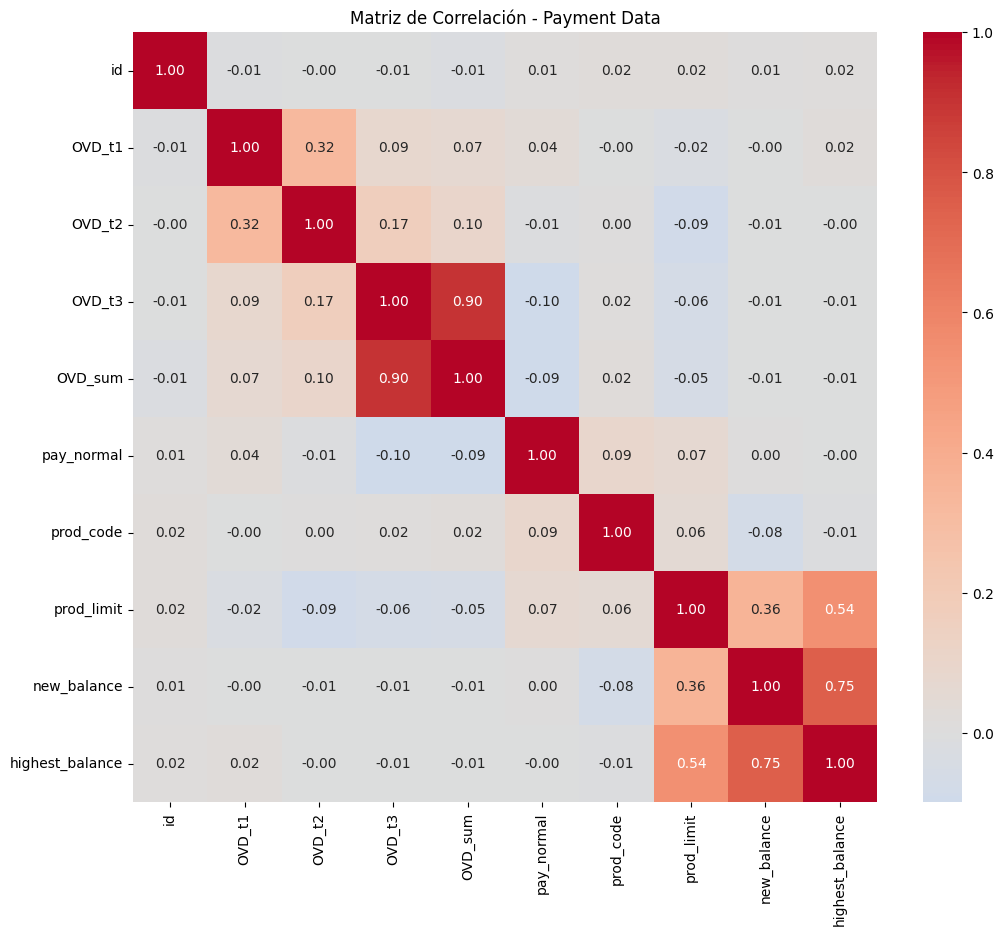

In [66]:
# 8. Matriz de correlación de payment_data
payment_numeric = payment_data.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 10))
sns.heatmap(payment_numeric.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlación - Payment Data')
plt.show()

In [67]:
# Agregar payment_data ANTES del merge
payment_agg = payment_data.groupby('id').agg({
    'OVD_t1': ['sum', 'mean', 'max'],
    'OVD_t2': ['sum', 'mean', 'max'],
    'OVD_t3': ['sum', 'mean', 'max'],
    'OVD_sum': ['sum', 'mean', 'max'],
    'pay_normal': ['sum', 'mean'],
    'prod_limit': ['mean', 'max'],
    'new_balance': ['sum', 'mean'],
    'highest_balance': ['max']
}).reset_index()

# Aplanar nombres de columnas
payment_agg.columns = ['_'.join(col).strip() for col in payment_agg.columns.values]
payment_agg.rename(columns={'id_': 'id'}, inplace=True)

# Hacer merge
df = pd.merge(customer_data, payment_agg, on='id', how='inner')

In [68]:
df.head()

,label,id,fea_1,fea_2,fea_3,fea_4,fea_5,fea_6,fea_7,fea_8,...,OVD_sum_sum,OVD_sum_mean,OVD_sum_max,pay_normal_sum,pay_normal_mean,prod_limit_mean,prod_limit_max,new_balance_sum,new_balance_mean,highest_balance_max
0,1,54982665,5,1245.5,3,77000.0,2,15,5,109,...,11906,2976.5,11906,34,8.500000,60500.000000,60500.0,160449.6,40112.400000,150500.0
1,0,59004779,4,1277.0,1,113000.0,2,8,-1,100,...,195,13.0,195,174,11.600000,69666.666667,129800.0,30607.2,2040.480000,360500.0
2,0,58990862,7,1298.0,1,110000.0,2,11,-1,101,...,0,0.0,0,64,10.666667,102300.000000,102300.0,655072.8,109178.800000,250500.0
3,1,58995168,7,1335.5,1,151000.0,2,11,5,110,...,0,0.0,0,92,23.000000,92400.000000,127600.0,16279.2,4069.800000,160500.0
4,0,54987320,7,NaN,2,59000.0,2,11,5,108,...,0,0.0,0,193,21.444444,154733.333333,247500.0,2343270.0,260363.333333,1500500.0


In [69]:
df.shape

(1125, 32)

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1125 entries, 0 to 1124
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   label                1125 non-null   int64  
 1   id                   1125 non-null   int64  
 2   fea_1                1125 non-null   int64  
 3   fea_2                976 non-null    float64
 4   fea_3                1125 non-null   int64  
 5   fea_4                1125 non-null   float64
 6   fea_5                1125 non-null   int64  
 7   fea_6                1125 non-null   int64  
 8   fea_7                1125 non-null   int64  
 9   fea_8                1125 non-null   int64  
 10  fea_9                1125 non-null   int64  
 11  fea_10               1125 non-null   int64  
 12  fea_11               1125 non-null   float64
 13  OVD_t1_sum           1125 non-null   int64  
 14  OVD_t1_mean          1125 non-null   float64
 15  OVD_t1_max           1125 non-null   i

In [71]:
customer_data.shape[0], payment_data.shape[0], df.shape[0]

(1125, 8250, 1125)

In [72]:
df.isnull().sum()

label                    0
id                       0
fea_1                    0
fea_2                  149
fea_3                    0
fea_4                    0
fea_5                    0
fea_6                    0
fea_7                    0
fea_8                    0
fea_9                    0
fea_10                   0
fea_11                   0
OVD_t1_sum               0
OVD_t1_mean              0
OVD_t1_max               0
OVD_t2_sum               0
OVD_t2_mean              0
OVD_t2_max               0
OVD_t3_sum               0
OVD_t3_mean              0
OVD_t3_max               0
OVD_sum_sum              0
OVD_sum_mean             0
OVD_sum_max              0
pay_normal_sum           0
pay_normal_mean          0
prod_limit_mean        180
prod_limit_max         180
new_balance_sum          0
new_balance_mean         0
highest_balance_max      0
dtype: int64

In [74]:
# 1. Correlación de variables agregadas de pago con LABEL
payment_agg_cols = [col for col in df.columns if col not in ['label', 'id', 'fea_1', 'fea_2', 'fea_3', 
                                                                'fea_4', 'fea_5', 'fea_6', 'fea_7', 
                                                                'fea_8', 'fea_9', 'fea_10', 'fea_11']]

correlation_with_label = df[payment_agg_cols + ['label']].corr()['label'].sort_values(ascending=False)
correlation_with_label

label                  1.000000
OVD_t2_mean            0.145016
OVD_t2_max             0.108425
OVD_t1_mean            0.093676
new_balance_mean       0.091592
OVD_t3_mean            0.087625
OVD_t2_sum             0.087344
OVD_sum_mean           0.082074
OVD_t1_max             0.073902
highest_balance_max    0.070354
new_balance_sum        0.068911
OVD_sum_max            0.068445
OVD_sum_sum            0.066050
OVD_t3_max             0.063707
OVD_t1_sum             0.057353
OVD_t3_sum             0.056406
prod_limit_mean       -0.065956
prod_limit_max        -0.102271
pay_normal_sum        -0.129282
pay_normal_mean       -0.131461
Name: label, dtype: float64

In [ ]:
correlation_with_label[correlation_with_label < 0].sort_values()

pay_normal_mean   -0.131461
pay_normal_sum    -0.129282
prod_limit_max    -0.102271
prod_limit_mean   -0.065956
Name: label, dtype: float64

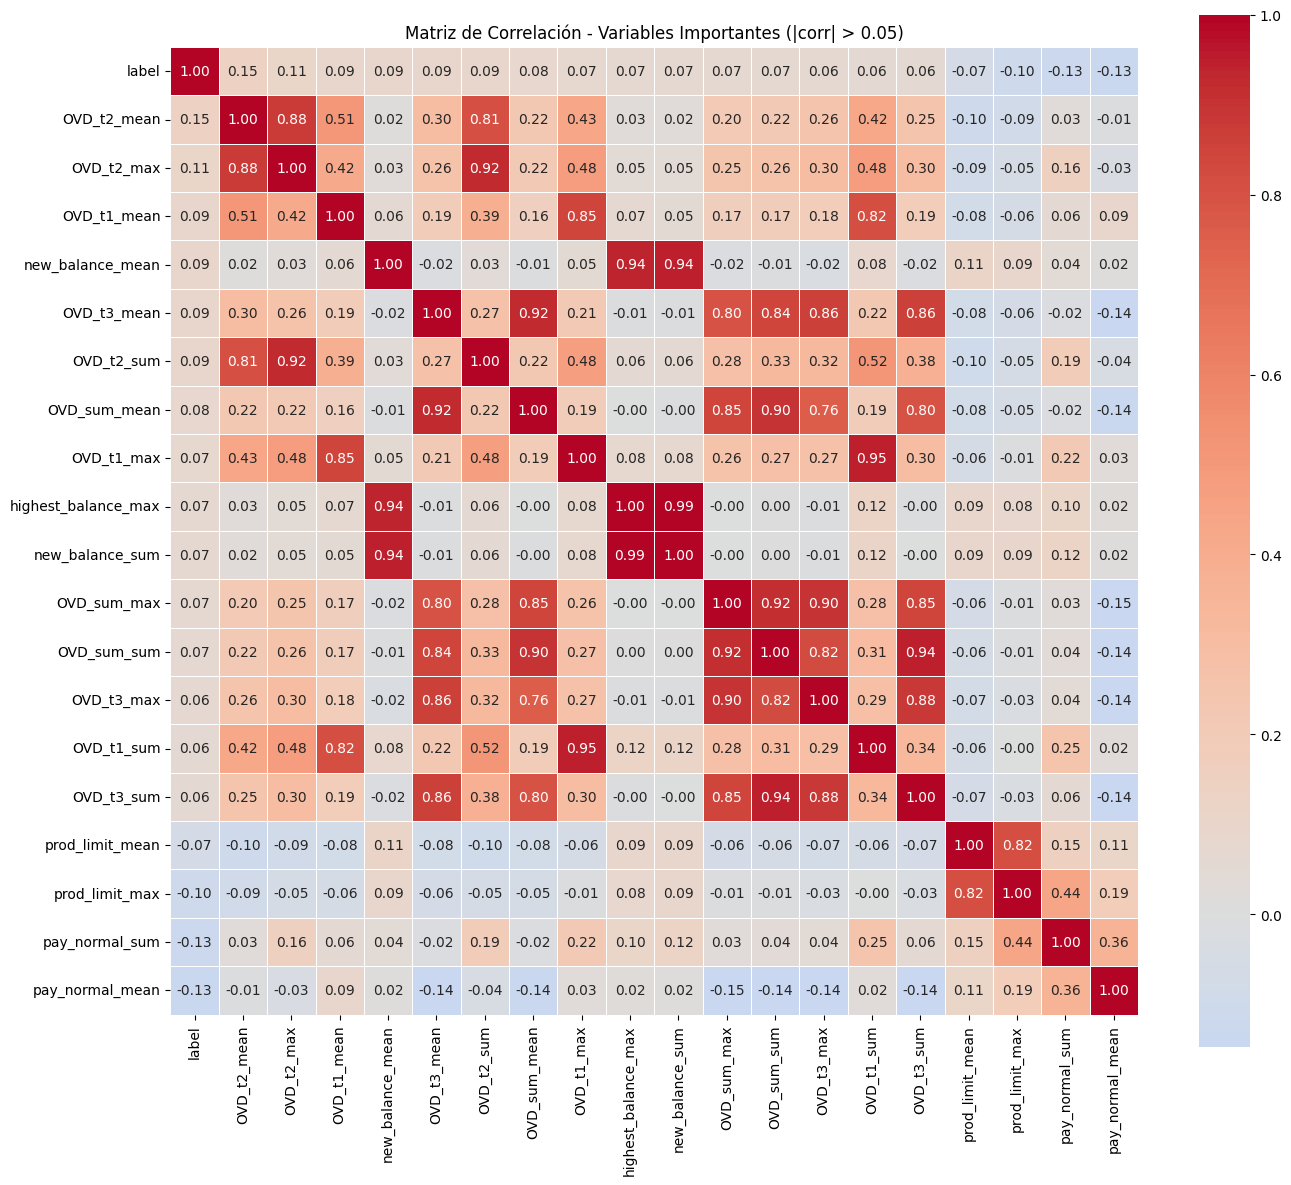

In [76]:
# Matriz de correlación completa de las principales variables
important_cols = correlation_with_label[abs(correlation_with_label) > 0.05].index.tolist()

plt.figure(figsize=(14, 12))
sns.heatmap(df[important_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, linewidths=0.5)
plt.title('Matriz de Correlación - Variables Importantes (|corr| > 0.05)')
plt.tight_layout()
plt.show()

In [77]:
# 1. Ratios y Proporciones de Atrasos
# Ratio total de atrasos vs pagos normales
df['ovd_to_normal_ratio'] = df['OVD_sum_sum'] / (df['pay_normal_sum'] + 1)

# Proporción de cada tipo de atraso
df['ovd_t1_proportion'] = df['OVD_t1_sum'] / (df['OVD_sum_sum'] + 1)
df['ovd_t2_proportion'] = df['OVD_t2_sum'] / (df['OVD_sum_sum'] + 1)
df['ovd_t3_proportion'] = df['OVD_t3_sum'] / (df['OVD_sum_sum'] + 1)

# Severidad promedio de atrasos (ponderado)
df['ovd_severity'] = (df['OVD_t1_sum'] * 1 + df['OVD_t2_sum'] * 2 + df['OVD_t3_sum'] * 3) / (df['OVD_sum_sum'] + 1)

In [78]:
# 2. Indicadores binarios (flags)
df['has_any_ovd'] = (df['OVD_sum_sum'] > 0).astype(int)
df['has_ovd_t2'] = (df['OVD_t2_sum'] > 0).astype(int)
df['has_ovd_t3'] = (df['OVD_t3_sum'] > 0).astype(int)
df['has_multiple_ovd_types'] = ((df['OVD_t1_sum'] > 0) + (df['OVD_t2_sum'] > 0) + (df['OVD_t3_sum'] > 0)).apply(lambda x: 1 if x >= 2 else 0)

In [79]:
# 3. Variables de Crédito y Balance
df['credit_utilization'] = df['new_balance_mean'] / (df['prod_limit_mean'] + 1)
df['max_utilization'] = df['highest_balance_max'] / (df['prod_limit_max'] + 1)
df['balance_growth'] = df['highest_balance_max'] / (df['new_balance_mean'] + 1)

# Capacidad de pago
df['payment_capacity'] = df['pay_normal_sum'] / (df['prod_limit_mean'] + 1)

In [80]:
# 4. Interacciones entre variables
df['ovd_max_per_transaction'] = df['OVD_sum_max']  # Ya existe pero lo hacemos explícito
df['consistency_score'] = df['pay_normal_mean'] / (df['OVD_sum_mean'] + 1)

# Riesgo compuesto
df['risk_score'] = (df['OVD_sum_sum'] * df['credit_utilization']) / (df['pay_normal_sum'] + 1)

In [81]:
# 5. Variables temporales/frecuencia
# Frecuencia de atrasos (promedio por registro)
df['ovd_frequency'] = df['OVD_sum_mean']
df['normal_payment_frequency'] = df['pay_normal_mean']

In [82]:
# Ver todas las nuevas features creadas
new_features = ['ovd_to_normal_ratio', 'ovd_t1_proportion', 'ovd_t2_proportion', 'ovd_t3_proportion',
                'ovd_severity', 'has_any_ovd', 'has_ovd_t2', 'has_ovd_t3', 'has_multiple_ovd_types',
                'credit_utilization', 'max_utilization', 'balance_growth', 'payment_capacity',
                'consistency_score', 'risk_score', 'ovd_frequency', 'normal_payment_frequency']

df[new_features].head(10)

,ovd_to_normal_ratio,ovd_t1_proportion,ovd_t2_proportion,ovd_t3_proportion,ovd_severity,has_any_ovd,has_ovd_t2,has_ovd_t3,has_multiple_ovd_types,credit_utilization,max_utilization,balance_growth,payment_capacity,consistency_score,risk_score,ovd_frequency,normal_payment_frequency
0,340.171429,0.000000,0.000168,0.002184,0.006887,1,1,1,0,0.663004,2.487562,3.751863,0.000562,0.002855,225.534990,2976.500000,8.500000
1,1.114286,0.010204,0.010204,0.000000,0.030612,1,1,0,0,0.029289,2.777328,176.587574,0.002498,0.828571,0.032636,13.000000,11.600000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1.067231,2.448656,2.294380,0.000626,10.666667,0.000000,0.000000,10.666667
3,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0,0,0.044045,1.257827,39.427140,0.000996,23.000000,0.000000,0.000000,23.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1.682647,6.062602,5.763078,0.001247,21.444444,0.000000,0.000000,21.444444
5,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1.622102,5.839025,4.386994,0.001392,16.333333,0.000000,0.000000,16.333333
6,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0,0,NaN,NaN,3.867873,NaN,14.000000,NaN,0.000000,14.000000
7,1.296296,0.037736,0.009434,0.000000,0.056604,1,1,0,0,0.886276,2.091162,3.190131,0.003073,0.733945,1.148876,26.250000,20.000000
8,233.373494,0.000413,0.000000,0.001239,0.004130,1,0,1,0,2.333903,15.463726,11.391442,0.000872,0.004232,544.671035,2767.142857,11.714286
9,1.030794,0.047096,0.015699,0.000000,0.078493,1,1,0,0,0.616656,6.436480,11.063806,0.005600,0.900585,0.635646,13.250000,12.833333


In [83]:
# Verificar valores infinitos o NaN
df[new_features].isnull().sum()

ovd_to_normal_ratio           0
ovd_t1_proportion             0
ovd_t2_proportion             0
ovd_t3_proportion             0
ovd_severity                  0
has_any_ovd                   0
has_ovd_t2                    0
has_ovd_t3                    0
has_multiple_ovd_types        0
credit_utilization          180
max_utilization             180
balance_growth                0
payment_capacity            180
consistency_score             0
risk_score                  180
ovd_frequency                 0
normal_payment_frequency      0
dtype: int64

In [84]:
# Reemplazar infinitos con NaN y luego con 0
df[new_features] = df[new_features].replace([np.inf, -np.inf], np.nan).fillna(0)

In [85]:
# Correlación de las NUEVAS features con label
new_correlations = df[new_features + ['label']].corr()['label'].sort_values(ascending=False)
new_correlations

label                       1.000000
credit_utilization          0.114471
max_utilization             0.093703
has_ovd_t2                  0.083501
has_any_ovd                 0.083458
ovd_to_normal_ratio         0.083323
ovd_frequency               0.082074
has_ovd_t3                  0.078873
ovd_t3_proportion           0.069284
ovd_t2_proportion           0.045193
risk_score                  0.035294
balance_growth             -0.019900
ovd_severity               -0.020572
ovd_t1_proportion          -0.026120
payment_capacity           -0.076670
normal_payment_frequency   -0.131461
consistency_score          -0.168620
has_multiple_ovd_types           NaN
Name: label, dtype: float64

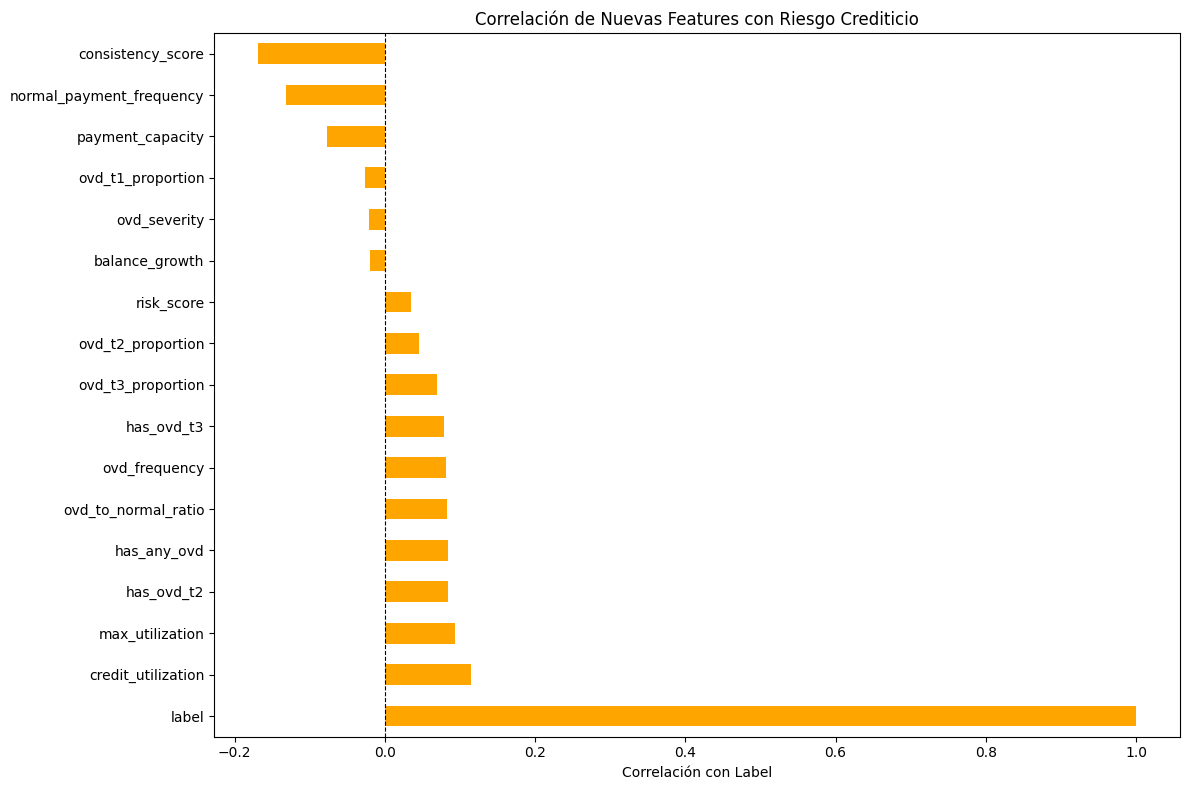

In [86]:
# Comparar mejores features nuevas vs originales
plt.figure(figsize=(12, 8))
new_correlations[:-1].plot(kind='barh', color='orange')
plt.title('Correlación de Nuevas Features con Riesgo Crediticio')
plt.xlabel('Correlación con Label')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

In [87]:
# Top 5 nuevas features
top_new_features = new_correlations[:-1].abs().sort_values(ascending=False).head(5)
top_new_features

label                       1.000000
consistency_score           0.168620
normal_payment_frequency    0.131461
credit_utilization          0.114471
max_utilization             0.093703
Name: label, dtype: float64

In [89]:
# 6. Polinomios y transformaciones (CORREGIDO)
df['ovd_sum_squared'] = df['OVD_sum_sum'] ** 2
df['ovd_sum_log'] = np.log1p(df['OVD_sum_sum'])  # log(1+x) para evitar log(0)
df['pay_normal_log'] = np.log1p(df['pay_normal_sum'])

# Ratio exponencial (CORREGIDO - limitamos el ratio antes de aplicar exp)
ovd_ratio = df['OVD_sum_sum'] / (df['pay_normal_sum'] + 1)
# Limitamos el ratio a un máximo de 10 para evitar overflow
ovd_ratio_clipped = np.clip(ovd_ratio, 0, 10)
df['ovd_exponential_ratio'] = np.exp(ovd_ratio_clipped) - 1

In [90]:
# 7. Combinaciones de las mejores variables existentes
# Combinación de atrasos graves con utilización de crédito
df['severe_ovd_high_util'] = df['OVD_t3_sum'] * df['credit_utilization']

# Combinación de atrasos totales con falta de pagos normales
df['ovd_low_payment'] = df['OVD_sum_sum'] * (1 / (df['pay_normal_sum'] + 1))

# Score de comportamiento peligroso
df['danger_score'] = (df['OVD_t3_sum'] * 3 + df['OVD_t2_sum'] * 2) / (df['pay_normal_sum'] + 1)

In [92]:
# 8. Percentiles y bins (CORREGIDO)
# Crear variable categórica de riesgo por OVD
df['ovd_category'] = pd.cut(df['OVD_sum_sum'], 
                              bins=[-np.inf, 0, 1, 5, 20, np.inf], 
                              labels=[0, 1, 2, 3, 4])
df['ovd_category'] = df['ovd_category'].cat.codes  # Esto convierte a int manejando NaN como -1

# Categoría de utilización de crédito
df['utilization_category'] = pd.cut(df['credit_utilization'], 
                                      bins=[-np.inf, 0, 0.3, 0.7, 1.0, np.inf], 
                                      labels=[0, 1, 2, 3, 4])
df['utilization_category'] = df['utilization_category'].cat.codes

In [93]:
# 9. Interacciones con variables demográficas (fea_*)
# Interacción de atrasos con features categóricas
for fea in ['fea_1', 'fea_3', 'fea_5', 'fea_6', 'fea_7', 'fea_9']:
    df[f'ovd_x_{fea}'] = df['OVD_sum_sum'] * df[fea]
    df[f'consistency_x_{fea}'] = df['consistency_score'] * df[fea]

In [94]:
# 10. Ratios específicos más agresivos
df['ovd_per_payment'] = df['OVD_sum_sum'] / (df['pay_normal_sum'] + df['OVD_sum_sum'] + 1)
df['severe_ovd_ratio'] = df['OVD_t3_sum'] / (df['OVD_sum_sum'] + 1)
df['payment_reliability'] = df['pay_normal_sum'] / (df['pay_normal_sum'] + df['OVD_sum_sum'] + 1)

In [95]:
# Limpiar infinitos y NaN
df = df.replace([np.inf, -np.inf], np.nan)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

In [97]:
# Correlación de TODAS las nuevas features
all_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
all_numeric.remove('id')

all_correlations = df[all_numeric].corr()['label'].sort_values(ascending=False)
all_correlations.head(20)

label                    1.000000
OVD_t2_mean              0.145016
ovd_per_payment          0.133823
credit_utilization       0.114471
ovd_sum_log              0.113123
danger_score             0.110877
ovd_exponential_ratio    0.108581
OVD_t2_max               0.108425
ovd_category             0.098497
max_utilization          0.093703
OVD_t1_mean              0.093676
new_balance_mean         0.091592
OVD_t3_mean              0.087625
OVD_t2_sum               0.087344
has_ovd_t2               0.083501
has_any_ovd              0.083458
ovd_low_payment          0.083323
ovd_to_normal_ratio      0.083323
OVD_sum_mean             0.082074
ovd_frequency            0.082074
Name: label, dtype: float64

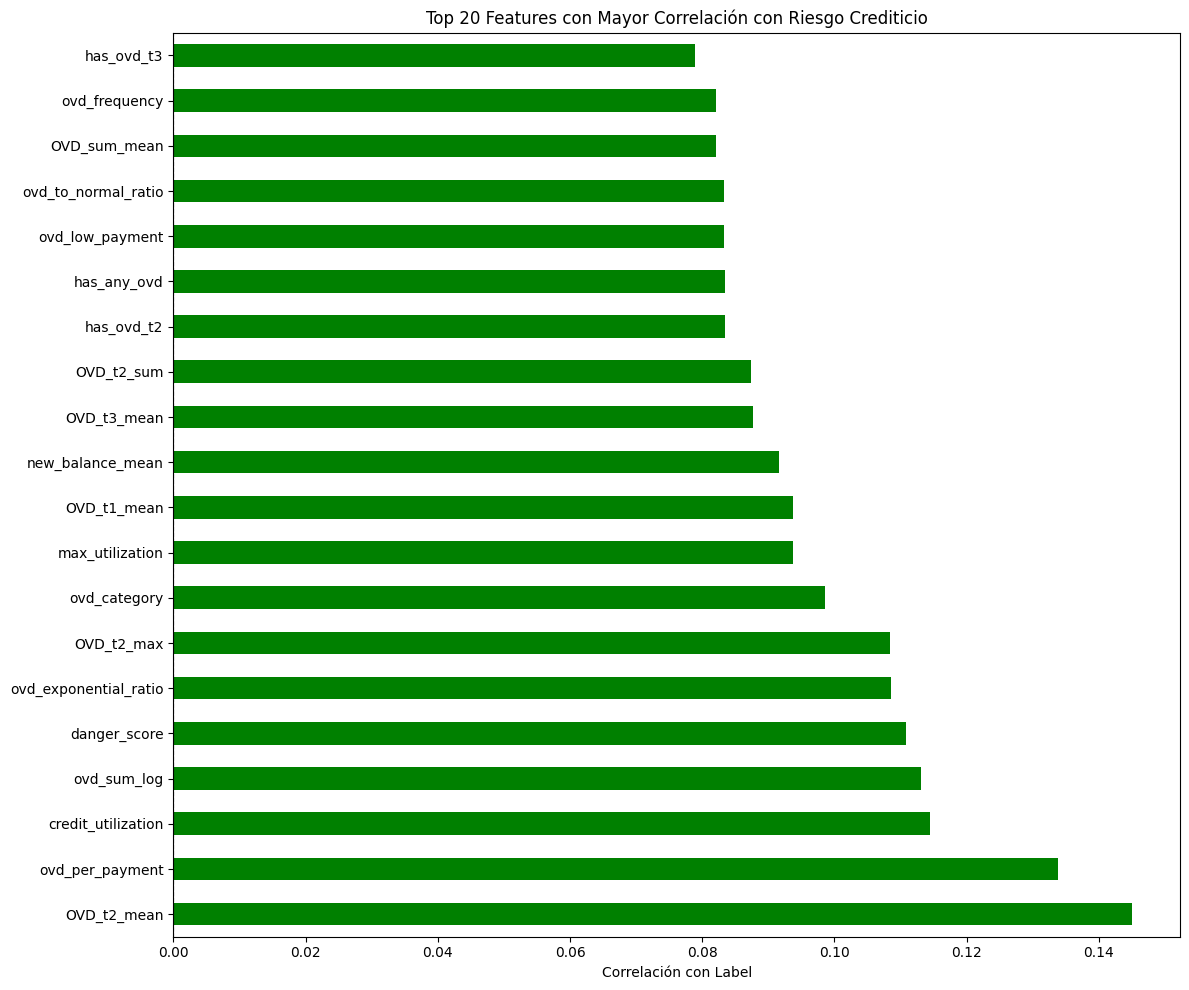

In [99]:
# Visualizar top 20
plt.figure(figsize=(12, 10))
all_correlations[1:21].plot(kind='barh', color='green')
plt.title('Top 20 Features con Mayor Correlación con Riesgo Crediticio')
plt.xlabel('Correlación con Label')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

In [100]:
# Verificar cuántas features nuevas creamos
original_cols = 32  # Era el número original después del merge
current_cols = df.shape[1]
print(f"Columnas originales: {original_cols}")
print(f"Columnas actuales: {current_cols}")
print(f"Nuevas features creadas: {current_cols - original_cols}")

Columnas originales: 32
Columnas actuales: 74
Nuevas features creadas: 42


In [101]:
# Ver TOP 20 correlaciones
all_correlations.head(20)

label                    1.000000
OVD_t2_mean              0.145016
ovd_per_payment          0.133823
credit_utilization       0.114471
ovd_sum_log              0.113123
danger_score             0.110877
ovd_exponential_ratio    0.108581
OVD_t2_max               0.108425
ovd_category             0.098497
max_utilization          0.093703
OVD_t1_mean              0.093676
new_balance_mean         0.091592
OVD_t3_mean              0.087625
OVD_t2_sum               0.087344
has_ovd_t2               0.083501
has_any_ovd              0.083458
ovd_low_payment          0.083323
ovd_to_normal_ratio      0.083323
OVD_sum_mean             0.082074
ovd_frequency            0.082074
Name: label, dtype: float64

In [103]:
# CORRECCIÓN: Excluir 'label' de las features antes de calcular
print("=" * 60)
print("COMPARACIÓN DE CORRELACIONES")
print("=" * 60)

# Features originales (sin label)
original_features = ['fea_1', 'fea_2', 'fea_3', 'fea_4', 'fea_5', 'fea_6', 'fea_7', 
                     'fea_8', 'fea_9', 'fea_10', 'fea_11',
                     'OVD_t1_sum', 'OVD_t1_mean', 'OVD_t1_max',
                     'OVD_t2_sum', 'OVD_t2_mean', 'OVD_t2_max',
                     'OVD_t3_sum', 'OVD_t3_mean', 'OVD_t3_max',
                     'OVD_sum_sum', 'OVD_sum_mean', 'OVD_sum_max',
                     'pay_normal_sum', 'pay_normal_mean',
                     'prod_limit_mean', 'prod_limit_max',
                     'new_balance_sum', 'new_balance_mean',
                     'highest_balance_max']

original_corr_values = df[original_features + ['label']].corr()['label'].drop('label')
best_original = original_corr_values.abs().max()
best_original_feature = original_corr_values.abs().idxmax()

# Todas las correlaciones (sin label)
all_corr_no_label = all_correlations.drop('label', errors='ignore')
best_new = all_corr_no_label.abs().max()
best_new_feature = all_corr_no_label.abs().idxmax()

print(f"\nMejor feature ORIGINAL: {best_original_feature}")
print(f"Correlación: {original_corr_values[best_original_feature]:.4f}")

print(f"\nMejor feature NUEVA: {best_new_feature}")
print(f"Correlación: {all_corr_no_label[best_new_feature]:.4f}")

print(f"\nMejora: {((best_new - best_original) / best_original * 100):.2f}%")

COMPARACIÓN DE CORRELACIONES

Mejor feature ORIGINAL: prod_limit_max
Correlación: -0.1515

Mejor feature NUEVA: consistency_score
Correlación: -0.1686

Mejora: 11.26%


In [108]:
df.to_csv(r'C:\Proyectos\Credit Risk Classification\df_limpio.csv', index=False)